# 🍌 Banana Leaf Disease Detection — Zero-Shot with LLaVA-1.5-7B

**Phase 1: Zero-Shot Accuracy Benchmarking**

This notebook evaluates LLaVA-1.5-7B's zero-shot ability to classify banana leaf images into:
- `HEALTHY`
- `CMV` (Cucumber Mosaic Virus)
- `SIGATOKA`

We test **multiple prompt strategies** and compare accuracy across them.

---

### Citation / Acknowledgement
If you use LLaVA in your research or project, please cite:
```
@misc{liu2023llava,
  title={Visual Instruction Tuning},
  author={Haotian Liu and Chunyuan Li and Qingyang Wu and Yong Jae Lee},
  year={2023},
  eprint={2304.08485},
  archivePrefix={arXiv}
}
```
Model weights are gated on Hugging Face — you must **accept the LLaVA-1.5 license** at: https://huggingface.co/llava-hf/llava-1.5-7b-hf

In [ ]:
!pip install --force-reinstall --no-deps "tokenizers==0.19.1"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 121.7 MB/s eta 0:00:00
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.22.2
    Uninstalling tokenizers-0.22.2:
      Successfully uninstalled tokenizers-0.22.2


In [ ]:
import tokenizers
print(tokenizers.__version__)  # Must print 0.19.1 before proceeding

0.19.1


## Step 0 — Runtime Check
Make sure you are on **A100 GPU + High-RAM** before proceeding.
Runtime → Change runtime type → A100, High-RAM

In [ ]:
import subprocess
result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
print(result.stdout)

import psutil
ram_gb = psutil.virtual_memory().total / (1024**3)
print(f"System RAM: {ram_gb:.1f} GB")

Sun Mar  1 10:24:42 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-80GB          Off |   00000000:00:05.0 Off |                    0 |
| N/A   33C    P0             55W /  400W |       0MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

## Step 1 — Install Dependencies

In [ ]:
# Run this first, then Runtime → Restart session
!pip install -q "transformers==4.40.0" "tokenizers==0.19.1" "accelerate==0.30.0"
print("Done! Now go to Runtime → Restart session")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.6/137.6 kB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 145.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.4/302.4 kB 36.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 55.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.2.3 requires transformers<6.0.0,>=4.41.0, but you have transformers 4.40.0 which is incompatible.
Done! Now go to Runtime → Restart session


## Step 2 — Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Step 3 — Configuration

Set your dataset root path below. The expected folder structure is:
```
DATASET_ROOT/
├── HEALTHY/          (folder name containing 'healthy')
├── CMV/              (folder name containing 'cmv')
└── SIGATOKA/         (folder name containing 'sigatoka')
```
The notebook auto-detects folder names — just set the root path.

In [ ]:
# ============================================================
#   USER CONFIG — Edit this section
# ============================================================

# Path to your banana dataset folder in Google Drive
DATASET_ROOT = "/content/drive/MyDrive/FINAL_DATASET_CROP_MONITORING"  # <--- YOUR PATH

# HuggingFace model ID
MODEL_ID = "llava-hf/llava-1.5-7b-hf"

# Split ratios
TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15
TEST_RATIO  = 0.15

# Inference settings
TEMPERATURE = 0
DO_SAMPLE   = False
TOP_P       = 1
MAX_NEW_TOKENS = 64

# Random seed for reproducibility
SEED = 42

# Run on test split (True) or val split (False)
EVALUATE_ON_TEST = True

# ============================================================

## Step 4 — Imports

In [ ]:
import os
import json
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from PIL import Image
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
import torch
from transformers import AutoProcessor, LlavaForConditionalGeneration

warnings.filterwarnings('ignore')

# Reproducibility
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")
if DEVICE == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Device: cuda
GPU: NVIDIA A100-SXM4-80GB
VRAM: 85.1 GB


## Step 5 — Load Dataset & Explore

In [ ]:
# Class mapping — auto-detect folders
CLASS_KEYWORDS = {
    "healthy":   "HEALTHY",
    "cmv":       "CMV",
    "sigatoka":  "SIGATOKA"
}

CLASS_LABELS = ["HEALTHY", "CMV", "SIGATOKA"]
LABEL_TO_IDX = {label: i for i, label in enumerate(CLASS_LABELS)}

def detect_class_from_folder(folder_name):
    folder_lower = folder_name.lower()
    for keyword, class_name in CLASS_KEYWORDS.items():
        if keyword in folder_lower:
            return class_name
    return None

image_paths = []
image_labels = []

dataset_root = Path(DATASET_ROOT)
assert dataset_root.exists(), f"Dataset path not found: {DATASET_ROOT}"

VALID_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.JPG'}

for folder in sorted(dataset_root.iterdir()):
    if not folder.is_dir():
        continue
    class_name = detect_class_from_folder(folder.name)
    if class_name is None:
        print(f"  Skipping unrecognised folder: {folder.name}")
        continue
    imgs = [f for f in folder.iterdir() if f.suffix.lower() in VALID_EXTS]
    print(f"  {folder.name:50s}  ->  {class_name:10s}  ({len(imgs)} images)")
    for img_path in imgs:
        image_paths.append(str(img_path))
        image_labels.append(class_name)

print(f"\nTotal images loaded: {len(image_paths)}")

# Class distribution
df_all = pd.DataFrame({'path': image_paths, 'label': image_labels})
print("\nClass distribution:")
print(df_all['label'].value_counts().to_string())

  CMV                                                 ->  CMV         (1048 images)
  HEALTHY                                             ->  HEALTHY     (938 images)
  SIGATOKA                                            ->  SIGATOKA    (1037 images)

Total images loaded: 3023

Class distribution:
label
CMV         1048
SIGATOKA    1037
HEALTHY      938


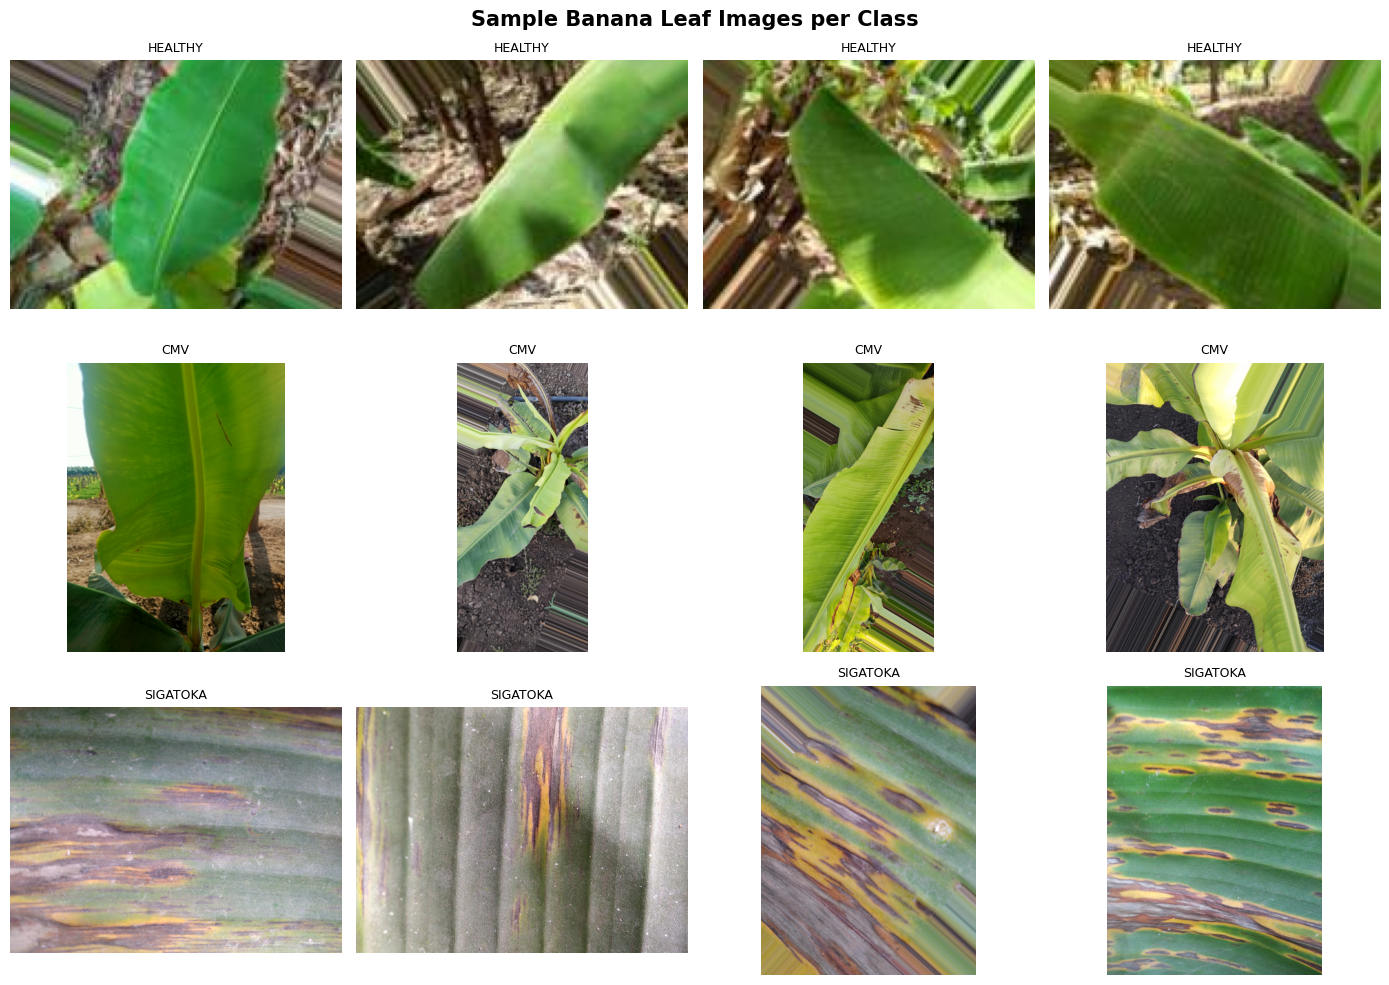

In [ ]:
# Visualise sample images
fig, axes = plt.subplots(3, 4, figsize=(14, 10))
fig.suptitle('Sample Banana Leaf Images per Class', fontsize=15, fontweight='bold')

for row_idx, class_name in enumerate(CLASS_LABELS):
    class_imgs = df_all[df_all['label'] == class_name]['path'].tolist()
    sample = random.sample(class_imgs, min(4, len(class_imgs)))
    for col_idx, img_path in enumerate(sample):
        ax = axes[row_idx][col_idx]
        img = Image.open(img_path).convert('RGB')
        ax.imshow(img)
        ax.set_title(class_name, fontsize=9)
        ax.axis('off')

plt.tight_layout()
plt.savefig('/content/sample_images.png', dpi=100, bbox_inches='tight')
plt.show()

## Step 6 — Stratified Train / Val / Test Split (70 / 15 / 15)

In [ ]:
paths  = df_all['path'].tolist()
labels = df_all['label'].tolist()

# First split off test set
paths_trainval, paths_test, labels_trainval, labels_test = train_test_split(
    paths, labels,
    test_size=TEST_RATIO,
    stratify=labels,
    random_state=SEED
)

# Then split train/val from trainval
val_ratio_adjusted = VAL_RATIO / (TRAIN_RATIO + VAL_RATIO)
paths_train, paths_val, labels_train, labels_val = train_test_split(
    paths_trainval, labels_trainval,
    test_size=val_ratio_adjusted,
    stratify=labels_trainval,
    random_state=SEED
)

print(f"Train : {len(paths_train):4d} images")
print(f"Val   : {len(paths_val):4d} images")
print(f"Test  : {len(paths_test):4d} images")
print(f"Total : {len(paths_train)+len(paths_val)+len(paths_test):4d} images")

# Verify class balance per split
for split_name, split_labels in [("Train", labels_train), ("Val", labels_val), ("Test", labels_test)]:
    counts = pd.Series(split_labels).value_counts()
    print(f"\n{split_name} class breakdown:")
    for cls in CLASS_LABELS:
        print(f"  {cls}: {counts.get(cls, 0)}")

Train : 2115 images
Val   :  454 images
Test  :  454 images
Total : 3023 images

Train class breakdown:
  HEALTHY: 656
  CMV: 734
  SIGATOKA: 725

Val class breakdown:
  HEALTHY: 141
  CMV: 157
  SIGATOKA: 156

Test class breakdown:
  HEALTHY: 141
  CMV: 157
  SIGATOKA: 156


In [ ]:
# Save splits as CSV for future reference
for split_name, split_paths, split_labels in [
    ("train", paths_train, labels_train),
    ("val",   paths_val,   labels_val),
    ("test",  paths_test,  labels_test)
]:
    pd.DataFrame({'path': split_paths, 'label': split_labels}).to_csv(
        f'/content/{split_name}_split.csv', index=False
    )

print("Splits saved to /content/")

# Select evaluation set
if EVALUATE_ON_TEST:
    eval_paths  = paths_test
    eval_labels = labels_test
    eval_name   = "Test"
else:
    eval_paths  = paths_val
    eval_labels = labels_val
    eval_name   = "Validation"

print(f"\nEvaluating on: {eval_name} split ({len(eval_paths)} images)")

Splits saved to /content/

Evaluating on: Test split (454 images)


## Step 7 — Load LLaVA-1.5-7B

> The model is loaded in **bfloat16** for optimal A100 performance. Full load time is ~2–3 minutes.

In [ ]:
print(f"Loading model: {MODEL_ID}")
print("This may take 2-3 minutes...")

from transformers import LlavaProcessor, LlamaTokenizer, CLIPImageProcessor

tokenizer = LlamaTokenizer.from_pretrained(MODEL_ID, use_fast=False)
image_processor = CLIPImageProcessor.from_pretrained(MODEL_ID)
processor = LlavaProcessor(image_processor=image_processor, tokenizer=tokenizer)

model = LlavaForConditionalGeneration.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.bfloat16,
    device_map="auto",
    low_cpu_mem_usage=True
)
model.eval()

print("\nModel loaded successfully!")
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params/1e9:.2f}B")
print(f"GPU VRAM used: {torch.cuda.memory_allocated()/1e9:.2f} GB")

Loading model: llava-hf/llava-1.5-7b-hf
This may take 2-3 minutes...


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/41.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/552 [00:00<?, ?B/s]

...

model-00002-of-00003.safetensors:   0%|          | 0.00/4.96G [00:00<?, ?B/s]

model-00003-of-00003.safetensors:   0%|          | 0.00/4.18G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/141 [00:00<?, ?B/s]


Model loaded successfully!
Total parameters: 7.06B
GPU VRAM used: 14.20 GB


## Step 8 — Define Prompt Strategies

We test **5 prompts** that vary in specificity, instruction style, and answer-format guidance.
All share the same generation settings: `temperature=0`, `do_sample=False`, `top_p=1`.

In [ ]:
# Each prompt is a plain-text question (no <image> tag — added automatically)
PROMPTS = {
    "P1_direct": (
        "Look at this banana leaf image. "
        "Classify it into exactly one of these three categories: "
        "HEALTHY, CMV, or SIGATOKA. "
        "Reply with only the category name and nothing else."
    ),
    "P2_reasoning": (
        "You are a plant pathology expert. Examine this banana leaf carefully. "
        "Think step-by-step about the visual symptoms you observe, then state "
        "the disease classification. "
        "Your final answer must be exactly one of: HEALTHY, CMV, SIGATOKA. "
        "End your response with: ANSWER: <classification>"
    ),
    "P3_symptoms": (
        "Examine this banana leaf. "
        "HEALTHY leaves are uniformly green with no spots, streaks, or lesions. "
        "CMV (Cucumber Mosaic Virus) causes mosaic patterns, yellow-green mottling, or leaf distortion. "
        "SIGATOKA causes yellow or brown streaks and spots that expand into necrotic lesions. "
        "Based on this, what is the single correct label for this leaf? "
        "Reply with only: HEALTHY, CMV, or SIGATOKA."
    ),
    "P4_forced_choice": (
        "This is a banana leaf disease classification task. "
        "You must pick exactly one answer from the following list: "
        "[HEALTHY, CMV, SIGATOKA]. "
        "Do not explain. Do not add extra text. Just output the label."
    ),
    "P5_visual_detail": (
        "Analyze this banana leaf photo for signs of disease. "
        "Look for: leaf color uniformity, mosaic patterns, yellow streaking, brown necrotic spots, and leaf distortion. "
        "Based solely on visual evidence, classify this leaf as one of: "
        "HEALTHY, CMV, or SIGATOKA. "
        "Output only the classification label."
    )
}

print(f"Defined {len(PROMPTS)} prompt strategies:")
for pname, ptext in PROMPTS.items():
    print(f"  {pname}: {ptext[:80]}...")

Defined 5 prompt strategies:
  P1_direct: Look at this banana leaf image. Classify it into exactly one of these three cate...
  P2_reasoning: You are a plant pathology expert. Examine this banana leaf carefully. Think step...
  P3_symptoms: Examine this banana leaf. HEALTHY leaves are uniformly green with no spots, stre...
  P4_forced_choice: This is a banana leaf disease classification task. You must pick exactly one ans...
  P5_visual_detail: Analyze this banana leaf photo for signs of disease. Look for: leaf color unifor...


## Step 9 — Response Parsing

Maps LLaVA's free-form text response to one of our 3 class labels.

In [ ]:
def parse_response(response_text):
    """
    Robust parser that maps LLaVA's output to one of the 3 class labels.
    Returns the matched class label, or 'Unknown' if nothing matched.
    """
    text = response_text.strip().lower()

    # For P2 reasoning prompt — extract ANSWER: ... if present
    if "answer:" in text:
        idx = text.rfind("answer:")
        text = text[idx + len("answer:"):].strip()

    # Priority order matters: check more specific terms first
    keyword_map = [
        # CMV patterns
        ("cmv",             "CMV"),
        ("cucumber mosaic", "CMV"),
        ("mosaic virus",    "CMV"),
        ("mosaic",          "CMV"),
        # Sigatoka patterns
        ("sigatoka",        "SIGATOKA"),
        ("black sigatoka",  "SIGATOKA"),
        ("yellow sigatoka", "SIGATOKA"),
        # Healthy patterns
        ("healthy",         "HEALTHY"),
        ("no disease",      "HEALTHY"),
        ("no sign",         "HEALTHY"),
        ("normal",          "HEALTHY"),
        ("no spot",         "HEALTHY"),
        ("not diseased",    "HEALTHY"),
        ("disease-free",    "HEALTHY"),
    ]

    for keyword, label in keyword_map:
        if keyword in text:
            return label

    return "Unknown"


# Quick sanity test
test_cases = [
    ("HEALTHY",                               "HEALTHY"),
    ("The leaf shows CMV infection.",         "CMV"),
    ("ANSWER: SIGATOKA",                      "SIGATOKA"),
    ("This plant looks normal and healthy.",  "HEALTHY"),
    ("mosaic pattern is visible",             "CMV"),
    ("sigatoka spots observed",               "SIGATOKA"),
]
all_pass = True
for text, expected in test_cases:
    result = parse_response(text)
    status = "PASS" if result == expected else "FAIL"
    if status == "FAIL":
        all_pass = False
    print(f"  [{status}] Input: '{text[:45]}' -> Got: '{result}', Expected: '{expected}'")

print(f"\nParser sanity check: {'ALL PASS' if all_pass else 'SOME FAILURES — review parser'}")

  [PASS] Input: 'HEALTHY' -> Got: 'HEALTHY', Expected: 'HEALTHY'
  [PASS] Input: 'The leaf shows CMV infection.' -> Got: 'CMV', Expected: 'CMV'
  [PASS] Input: 'ANSWER: SIGATOKA' -> Got: 'SIGATOKA', Expected: 'SIGATOKA'
  [PASS] Input: 'This plant looks normal and healthy.' -> Got: 'HEALTHY', Expected: 'HEALTHY'
  [PASS] Input: 'mosaic pattern is visible' -> Got: 'CMV', Expected: 'CMV'
  [PASS] Input: 'sigatoka spots observed' -> Got: 'SIGATOKA', Expected: 'SIGATOKA'

Parser sanity check: ALL PASS


## Step 10 — Zero-Shot Inference Loop

In [ ]:
def run_inference_single(image_path, prompt_text):
    """
    LLaVA-1.5 inference without apply_chat_template.
    Uses the native USER/ASSISTANT format directly.
    """
    image = Image.open(image_path).convert('RGB')

    # LLaVA-1.5 expects exactly this format
    formatted_prompt = f"USER: <image>\n{prompt_text}\nASSISTANT:"

    inputs = processor(
        images=image,
        text=formatted_prompt,
        return_tensors='pt'
    ).to(DEVICE, torch.bfloat16)

    with torch.inference_mode():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=MAX_NEW_TOKENS,
            do_sample=DO_SAMPLE,
            temperature=None,
            top_p=None
        )

    input_len     = inputs['input_ids'].shape[1]
    generated_ids = output_ids[:, input_len:]
    response      = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]

    return response.strip()


def evaluate_prompt(prompt_name, prompt_text, img_paths, true_labels):
    print(f"\nRunning: {prompt_name}")
    print("-" * 50)

    raw_responses = []
    predictions   = []
    unknown_count = 0

    for img_path, true_label in tqdm(zip(img_paths, true_labels),
                                      total=len(img_paths),
                                      desc=prompt_name):
        try:
            raw  = run_inference_single(img_path, prompt_text)
            pred = parse_response(raw)
        except Exception as e:
            raw  = f"ERROR: {e}"
            pred = "Unknown"

        raw_responses.append(raw)
        predictions.append(pred)
        if pred == "Unknown":
            unknown_count += 1

    valid_mask   = [p != "Unknown" for p in predictions]
    preds_valid  = [p for p, v in zip(predictions, valid_mask) if v]
    labels_valid = [l for l, v in zip(true_labels,  valid_mask) if v]

    acc_all   = accuracy_score(true_labels, predictions) * 100
    acc_valid = accuracy_score(labels_valid, preds_valid) * 100 if labels_valid else 0.0

    print(f"  Total images    : {len(img_paths)}")
    print(f"  Unknown / failed: {unknown_count} ({100*unknown_count/len(img_paths):.1f}%)")
    print(f"  Accuracy (all)  : {acc_all:.2f}%")
    print(f"  Accuracy (valid): {acc_valid:.2f}%")

    return {
        "prompt_name":   prompt_name,
        "prompt_text":   prompt_text,
        "raw_responses": raw_responses,
        "predictions":   predictions,
        "true_labels":   true_labels,
        "unknown_count": unknown_count,
        "acc_all":       acc_all,
        "acc_valid":     acc_valid
    }

# Quick sanity check on 1 image before full run
test_img   = eval_paths[0]
test_label = eval_labels[0]
test_raw   = run_inference_single(test_img, "What disease does this banana leaf have? Reply with: HEALTHY, CMV, or SIGATOKA.")
print(f"Sanity check — True: {test_label} | Raw response: '{test_raw}'")

Sanity check — True: SIGATOKA | Raw response: 'The banana leaf in the image has a disease called Sigatoka.'


## CHECK IF PARSER IS WORKING FINE

## Step 11 — Run All Prompts

This cell runs all 5 prompts sequentially on the evaluation split.
On A100 with test images, expect ~10–15 minutes per prompt.

> **Tip**: If you want a quick sanity check first, set `QUICK_TEST = True` below to run on 50 images only.

In [ ]:
# Set to True for a quick 50-image test run, False for full evaluation
QUICK_TEST = False

if QUICK_TEST:
    # Stratified sample of 50 images
    quick_idx = []
    for cls in CLASS_LABELS:
        cls_idx = [i for i, l in enumerate(eval_labels) if l == cls]
        sampled = random.sample(cls_idx, min(17, len(cls_idx)))
        quick_idx.extend(sampled)
    quick_idx = sorted(quick_idx)[:50]
    run_paths  = [eval_paths[i]  for i in quick_idx]
    run_labels = [eval_labels[i] for i in quick_idx]
    print(f"QUICK TEST MODE: {len(run_paths)} images")
else:
    run_paths  = eval_paths
    run_labels = eval_labels
    print(f"FULL EVALUATION: {len(run_paths)} images")

# Run all prompts
all_results = {}

for prompt_name, prompt_text in PROMPTS.items():
    result = evaluate_prompt(
        prompt_name  = prompt_name,
        prompt_text  = prompt_text,
        img_paths    = run_paths,
        true_labels  = run_labels
    )
    all_results[prompt_name] = result

    # Save intermediate results
    with open(f'/content/results_{prompt_name}.json', 'w') as f:
        json.dump({
            'prompt_name':   result['prompt_name'],
            'prompt_text':   result['prompt_text'],
            'acc_all':       result['acc_all'],
            'acc_valid':     result['acc_valid'],
            'unknown_count': result['unknown_count'],
            'predictions':   result['predictions'],
            'true_labels':   result['true_labels'],
            'raw_responses': result['raw_responses']
        }, f, indent=2)

print("\n" + "="*60)
print("ALL PROMPTS COMPLETE")
print("="*60)

FULL EVALUATION: 454 images

Running: P1_direct
--------------------------------------------------


P1_direct:   0%|          | 0/454 [00:00<?, ?it/s]

  Total images    : 454
  Unknown / failed: 0 (0.0%)
  Accuracy (all)  : 34.58%
  Accuracy (valid): 34.58%

Running: P2_reasoning
--------------------------------------------------


P2_reasoning:   0%|          | 0/454 [00:00<?, ?it/s]

  Total images    : 454
  Unknown / failed: 63 (13.9%)
  Accuracy (all)  : 30.62%
  Accuracy (valid): 35.55%

Running: P3_symptoms
--------------------------------------------------


...

  Total images    : 454
  Unknown / failed: 0 (0.0%)
  Accuracy (all)  : 31.72%
  Accuracy (valid): 31.72%

Running: P4_forced_choice
--------------------------------------------------


P4_forced_choice:   0%|          | 0/454 [00:00<?, ?it/s]

  Total images    : 454
  Unknown / failed: 0 (0.0%)
  Accuracy (all)  : 34.58%
  Accuracy (valid): 34.58%

Running: P5_visual_detail
--------------------------------------------------


P5_visual_detail:   0%|          | 0/454 [00:00<?, ?it/s]

  Total images    : 454
  Unknown / failed: 0 (0.0%)
  Accuracy (all)  : 48.24%
  Accuracy (valid): 48.24%

ALL PROMPTS COMPLETE


## Step 12 — Summary Table & Accuracy Comparison

In [ ]:
summary_rows = []
for pname, res in all_results.items():
    valid_mask = [p != "Unknown" for p in res['predictions']]
    preds_v    = [p for p, v in zip(res['predictions'], valid_mask) if v]
    labels_v   = [l for l, v in zip(res['true_labels'],  valid_mask) if v]

    # Per-class accuracy
    per_class = {}
    for cls in CLASS_LABELS:
        cls_true  = [l == cls for l in res['true_labels']]
        cls_pred  = [p == cls for p in res['predictions']]
        correct   = sum(t and p for t, p in zip(cls_true, cls_pred))
        total_cls = sum(cls_true)
        per_class[cls] = (correct / total_cls * 100) if total_cls > 0 else 0.0

    summary_rows.append({
        'Prompt':             pname,
        'Accuracy (all) %':   round(res['acc_all'],   2),
        'Accuracy (valid) %': round(res['acc_valid'],  2),
        'Unknowns':           res['unknown_count'],
        'HEALTHY Acc %':      round(per_class['HEALTHY'],   2),
        'CMV Acc %':          round(per_class['CMV'],       2),
        'SIGATOKA Acc %':     round(per_class['SIGATOKA'],  2),
    })

df_summary = pd.DataFrame(summary_rows).set_index('Prompt')
print(df_summary.to_string())
df_summary.to_csv('/content/prompt_comparison_summary.csv')
print("\nSummary saved to /content/prompt_comparison_summary.csv")

                  Accuracy (all) %  Accuracy (valid) %  Unknowns  HEALTHY Acc %  CMV Acc %  SIGATOKA Acc %
Prompt                                                                                                    
P1_direct                    34.58               34.58         0           0.00     100.00            0.00
P2_reasoning                 30.62               35.55        63           1.42      78.34            8.97
P3_symptoms                  31.72               31.72         0         100.00       1.91            0.00
P4_forced_choice             34.58               34.58         0           0.00     100.00            0.00
P5_visual_detail             48.24               48.24         0          98.58      50.96            0.00

Summary saved to /content/prompt_comparison_summary.csv


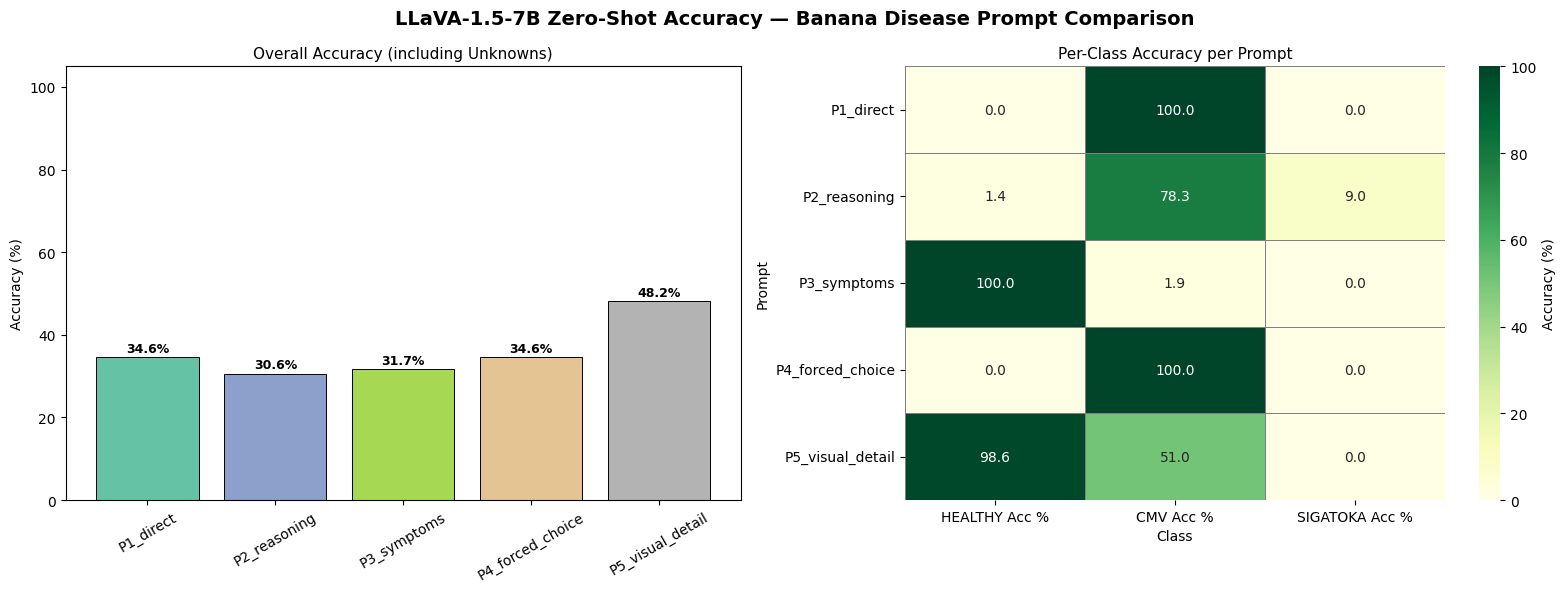

In [ ]:
# ---- Bar chart: Accuracy comparison across prompts ----
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('LLaVA-1.5-7B Zero-Shot Accuracy — Banana Disease Prompt Comparison', fontsize=14, fontweight='bold')

prompts  = df_summary.index.tolist()
acc_all  = df_summary['Accuracy (all) %'].tolist()
acc_val  = df_summary['Accuracy (valid) %'].tolist()
colors   = plt.cm.Set2(np.linspace(0, 1, len(prompts)))

# Left: overall accuracy
bars = axes[0].bar(prompts, acc_all, color=colors, edgecolor='black', linewidth=0.7)
axes[0].set_title('Overall Accuracy (including Unknowns)', fontsize=11)
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_ylim(0, 105)
axes[0].tick_params(axis='x', rotation=30)
for bar, val in zip(bars, acc_all):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Right: per-class accuracy heatmap
pc_data = df_summary[['HEALTHY Acc %', 'CMV Acc %', 'SIGATOKA Acc %']]
sns.heatmap(
    pc_data,
    ax=axes[1],
    annot=True, fmt='.1f', cmap='YlGn',
    vmin=0, vmax=100,
    linewidths=0.5, linecolor='gray',
    cbar_kws={'label': 'Accuracy (%)'}
)
axes[1].set_title('Per-Class Accuracy per Prompt', fontsize=11)
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Prompt')

plt.tight_layout()
plt.savefig('/content/accuracy_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

## Step 13 — Confusion Matrices per Prompt

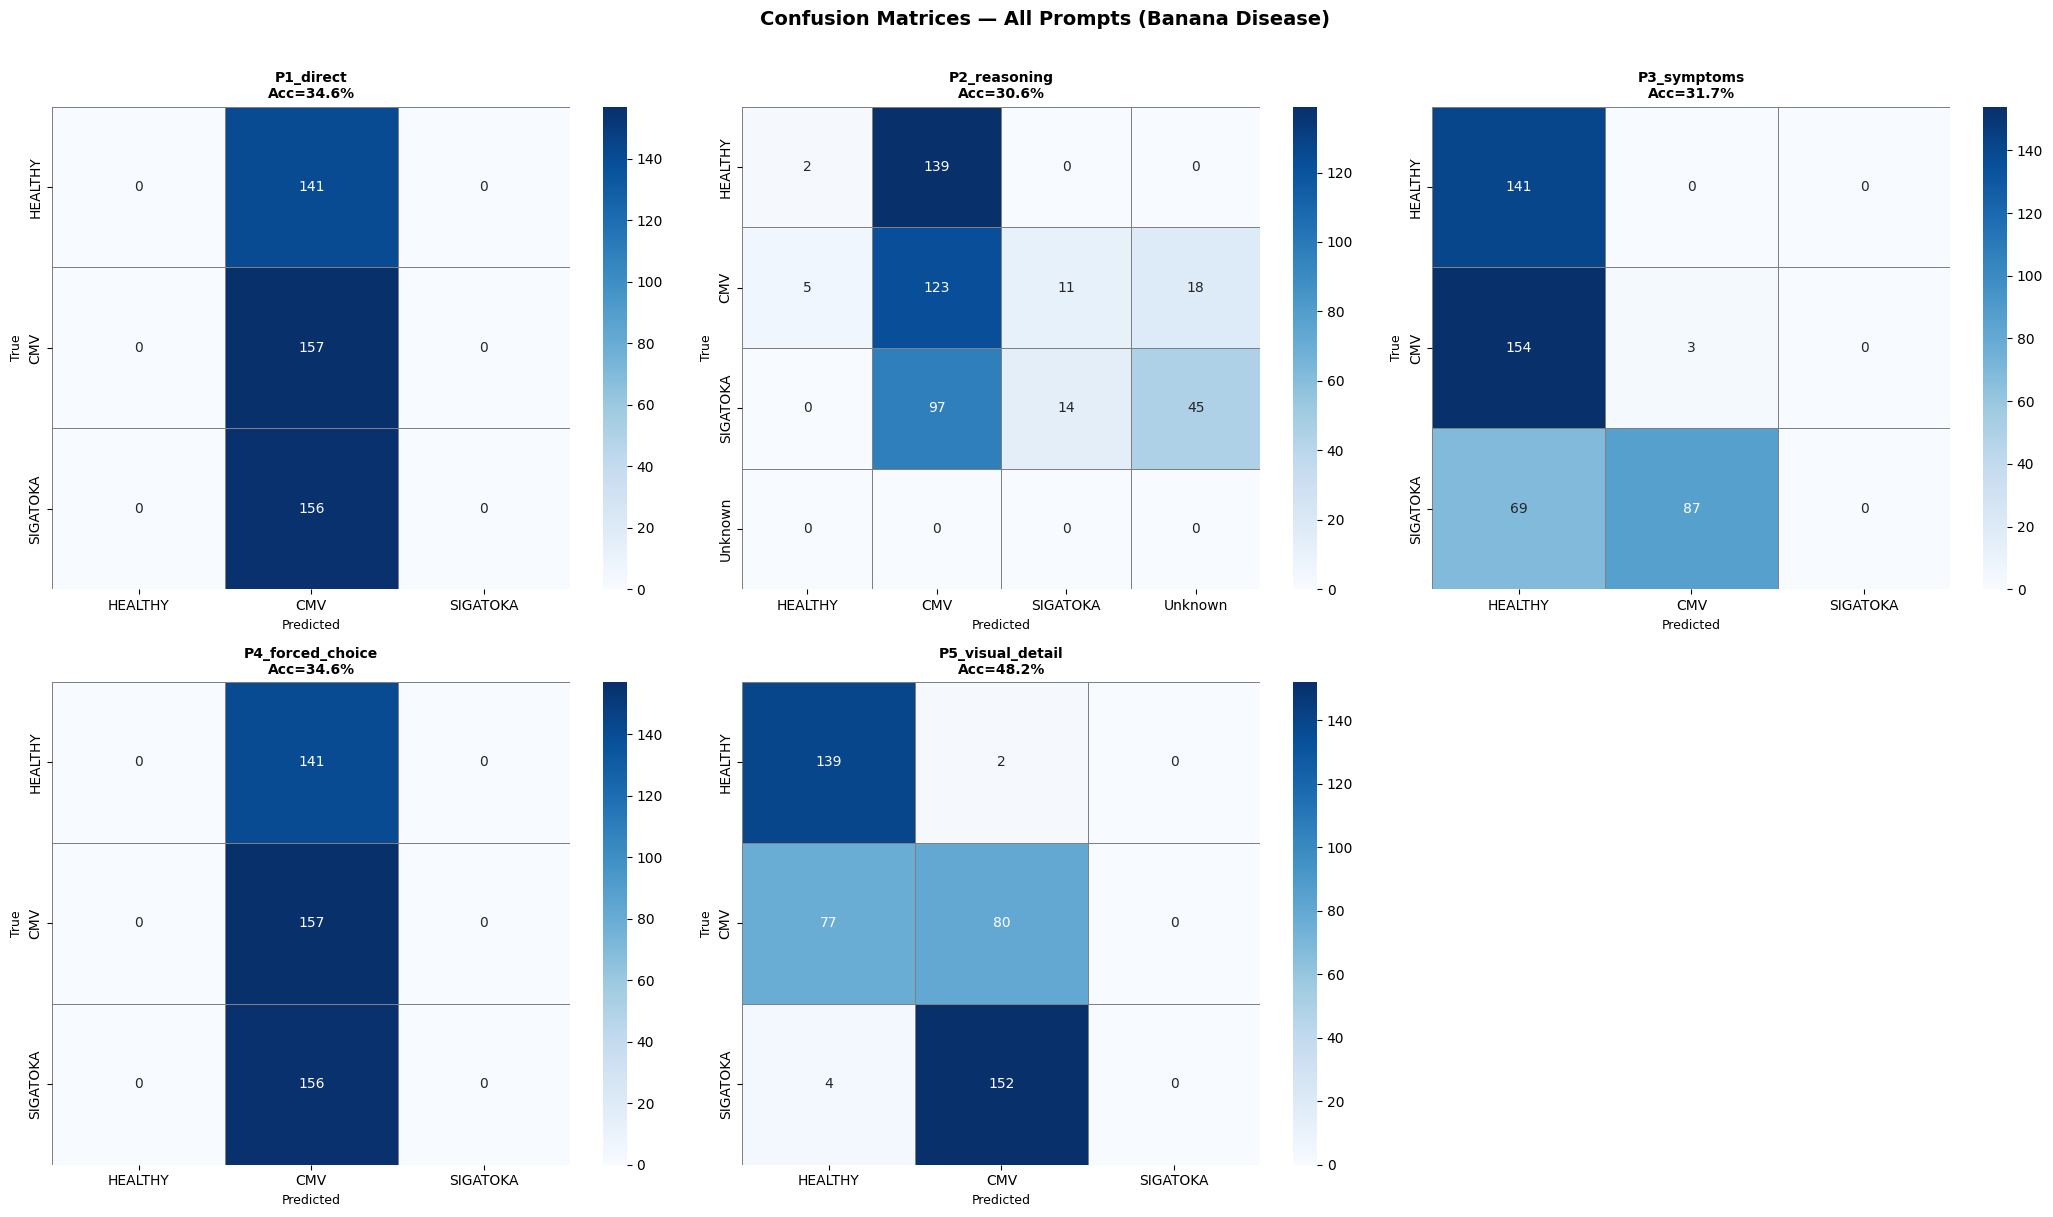

In [ ]:
n_prompts = len(all_results)
ncols = min(3, n_prompts)
nrows = (n_prompts + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 6 * nrows))
if n_prompts == 1:
    axes = np.array([[axes]])
elif nrows == 1:
    axes = axes.reshape(1, -1)

fig.suptitle('Confusion Matrices — All Prompts (Banana Disease)', fontsize=14, fontweight='bold', y=1.01)

for idx, (pname, res) in enumerate(all_results.items()):
    row, col = divmod(idx, ncols)
    ax = axes[row][col]

    unique_preds = sorted(set(res['predictions']))
    display_labels = [l for l in CLASS_LABELS + ["Unknown"] if l in unique_preds or l in CLASS_LABELS]

    cm = confusion_matrix(res['true_labels'], res['predictions'],
                          labels=display_labels)
    short = [l[:10] for l in display_labels]
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=short, yticklabels=short,
                ax=ax, linewidths=0.4, linecolor='gray')
    ax.set_title(f'{pname}\nAcc={res["acc_all"]:.1f}%', fontsize=10, fontweight='bold')
    ax.set_xlabel('Predicted', fontsize=9)
    ax.set_ylabel('True', fontsize=9)

# Hide unused subplot panels
for idx in range(n_prompts, nrows * ncols):
    row, col = divmod(idx, ncols)
    axes[row][col].set_visible(False)

plt.tight_layout()
plt.savefig('/content/confusion_matrices.png', dpi=120, bbox_inches='tight')
plt.show()

## Step 14 — Detailed Classification Report (Best Prompt)

In [ ]:
# Identify best prompt
best_prompt_name = max(all_results, key=lambda k: all_results[k]['acc_all'])
best_result      = all_results[best_prompt_name]

print(f"Best Prompt: {best_prompt_name}")
print(f"Accuracy   : {best_result['acc_all']:.2f}%")
print("=" * 60)
print(f"Prompt text:\n{best_result['prompt_text']}")
print("=" * 60)
print("\nDetailed Classification Report:")
print(classification_report(
    best_result['true_labels'],
    best_result['predictions'],
    labels=CLASS_LABELS,
    zero_division=0
))

Best Prompt: P5_visual_detail
Accuracy   : 48.24%
Prompt text:
Analyze this banana leaf photo for signs of disease. Look for: leaf color uniformity, mosaic patterns, yellow streaking, brown necrotic spots, and leaf distortion. Based solely on visual evidence, classify this leaf as one of: HEALTHY, CMV, or SIGATOKA. Output only the classification label.

Detailed Classification Report:
              precision    recall  f1-score   support

     HEALTHY       0.63      0.99      0.77       141
         CMV       0.34      0.51      0.41       157
    SIGATOKA       0.00      0.00      0.00       156

    accuracy                           0.48       454
   macro avg       0.32      0.50      0.39       454
weighted avg       0.31      0.48      0.38       454



## Step 15 — Inspect Failures (Best Prompt)

Total misclassifications: 235 / 454


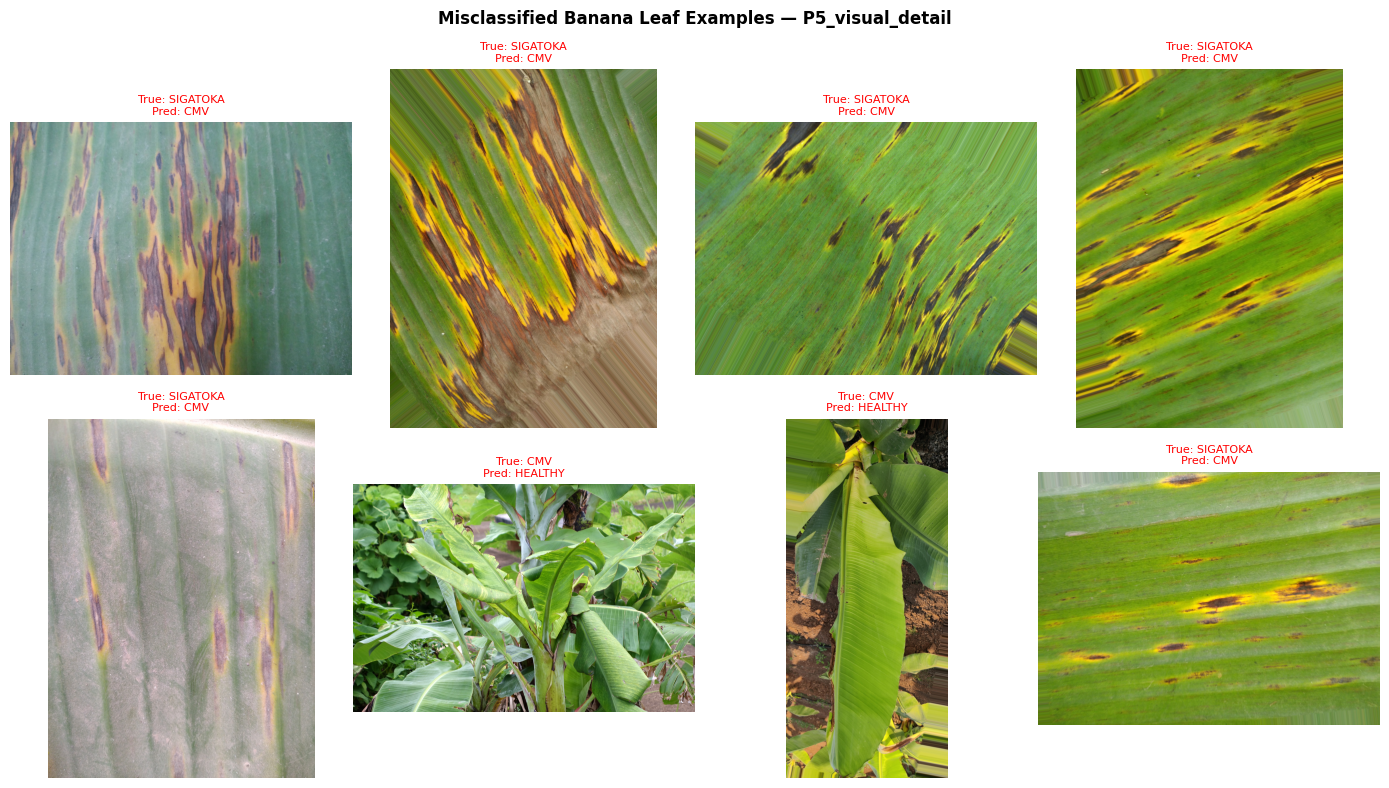

In [ ]:
# Show misclassified examples
failures = [
    (run_paths[i], run_labels[i], best_result['predictions'][i], best_result['raw_responses'][i])
    for i in range(len(run_paths))
    if best_result['predictions'][i] != run_labels[i]
]

print(f"Total misclassifications: {len(failures)} / {len(run_paths)}")

# Show up to 8 failure examples
show_n = min(8, len(failures))
if show_n > 0:
    ncols = 4
    nrows = (show_n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows))
    axes = axes.flatten() if hasattr(axes, 'flatten') else [axes]
    fig.suptitle(f'Misclassified Banana Leaf Examples — {best_prompt_name}', fontsize=12, fontweight='bold')

    for i, (img_path, true_lbl, pred_lbl, raw_resp) in enumerate(failures[:show_n]):
        img = Image.open(img_path).convert('RGB')
        axes[i].imshow(img)
        axes[i].set_title(
            f'True: {true_lbl}\nPred: {pred_lbl}',
            fontsize=8, color='red'
        )
        axes[i].axis('off')

    for j in range(show_n, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.savefig('/content/failure_examples.png', dpi=100, bbox_inches='tight')
    plt.show()
else:
    print("No misclassifications! Perfect accuracy.")

## Step 16 — Save All Results & Export to Google Drive

In [ ]:
import shutil, datetime

timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
output_dir = f"/content/drive/MyDrive/llava7b_banana_zeroshot_results_{timestamp}"
os.makedirs(output_dir, exist_ok=True)

# Copy all outputs to Drive
files_to_save = [
    '/content/prompt_comparison_summary.csv',
    '/content/accuracy_comparison.png',
    '/content/confusion_matrices.png',
    '/content/failure_examples.png',
    '/content/sample_images.png',
    '/content/train_split.csv',
    '/content/val_split.csv',
    '/content/test_split.csv',
]
for p in files_to_save:
    if os.path.exists(p):
        shutil.copy(p, output_dir)

# Save each prompt result JSON
for pname in all_results:
    src = f'/content/results_{pname}.json'
    if os.path.exists(src):
        shutil.copy(src, output_dir)

# Save combined summary JSON
summary_export = {}
for pname, res in all_results.items():
    summary_export[pname] = {
        'acc_all':       res['acc_all'],
        'acc_valid':     res['acc_valid'],
        'unknown_count': res['unknown_count'],
        'prompt_text':   res['prompt_text']
    }
with open(os.path.join(output_dir, 'combined_summary.json'), 'w') as f:
    json.dump(summary_export, f, indent=2)

print(f"All results saved to: {output_dir}")

# Print final summary table
print("\n" + "="*70)
print("FINAL ZERO-SHOT ACCURACY SUMMARY — BANANA DISEASE")
print("="*70)
print(df_summary[['Accuracy (all) %', 'Accuracy (valid) %', 'Unknowns']].to_string())
print("="*70)
print(f"Best Prompt: {best_prompt_name} ({best_result['acc_all']:.2f}% accuracy)")

---
## Notes for Phase 2

Now that we have zero-shot baselines, Phase 2 options include:

1. **Few-shot prompting** — inject 1–3 example images per class into the prompt context
2. **Fine-tuning LLaVA** — LoRA/QLoRA fine-tune on the training split
3. **Ensemble / chain-of-thought** — combine the best two prompts and take majority vote
4. **Data augmentation + fine-tuning** — flip, rotate, colour-jitter the training set before tuning

The train/val/test CSVs saved in this notebook carry over directly to Phase 2.